# Fixed Effects

**Author:** Alejandro Orellana

**Date:** Janurary 14, 2026

**Data Source:** Chicago Energy Benchmarking Dataset (2014-2023) - City of Chicago Open Data Portal  

## Section 1: Loading Data

In [1]:
from utils.data_utils import load_data
from utils.plot_utils import plot_model_coefficients
from utils.stats_utils import (
    fixed_effects_analysis,
    prepare_analysis,
    prepared_dataframe,
)

panel_data = prepared_dataframe(load_data())
target_col = "Weather Normalized Site EUI (kBtu/sq ft)"
rating_col = "Chicago Energy Rating"
analysis_df = prepare_analysis(panel_data, target_col, rating_col)
analysis_df.head()

2026-01-18 19:29:17,891 [INFO] generated new fontManager
2026-01-18 19:29:22,561 [INFO] ✅ COVID Impact Category assignment (with 'Other' group) complete.
2026-01-18 19:29:22,574 [INFO] Category counts:
COVID Impact Category
Other                    985
Permanent               2370
Stable/Increased       10171
Temporary/Rebounded     5378


----------------------------------------
DATA ANALYSIS PREP SUMMARY
----------------------------------------
Initial Total Rows:        18904
Initial Unique Buildings:  2363
----------------------------------------
Rows with Future Change:   12000
Unique Buildings Retained: 2352
Unique Buildings Lost: 11
----------------------------------------


,Data Year,ID,Property Name,Address,ZIP Code,Community Area,Primary Property Type,Gross Floor Area - Buildings (sq ft),Year Built,# of Buildings,...,Water Use (kGal),Row_ID,COVID Impact Category,Current_EUI,Next_Year_EUI,Future_Change_Raw,Future_Change,Rating_Numeric,Rating_Cat,Post_Policy
11603,2016,100001,presence smemc st elizabeth campus,1431 North Claremont Ave,60622,west town,hospital,309056.0,1928.0,1.0,...,NaN,nan,Other,194.6,186.9,-7.7,-7.7,NaN,None,0
2543,2017,100001,presence smemc st elizabeth campus,1431 North Claremont Ave,60622,west town,hospital,309056.0,1928.0,1.0,...,NaN,nan,Other,186.9,186.5,-0.4,-0.4,NaN,None,0
28282,2018,100001,presence smemc st elizabeth campus,1431 North Claremont Ave,60622,west town,hospital,309056.0,1928.0,1.0,...,67.0,nan,Other,186.5,NaN,NaN,NaN,NaN,None,0
20009,2019,100001,presence smemc st elizabeth campus,1431 N Claremont Ave,60622,west town,hospital,309056.0,1928.0,3.0,...,NaN,nan,Other,NaN,180.0,NaN,NaN,NaN,None,1
6268,2020,100001,presence smemc st elizabeth campus,1431 N Claremont Ave,60622,west town,hospital,505417.0,1928.0,3.0,...,NaN,nan,Other,180.0,175.3,-4.7,-4.7,NaN,None,1


# Fixed Effects Model

The prepare_analysis function constructs the target variable (Year-over-Year Change) and formats the Chicago Star Ratings. The fixed_effects_analysis function then models this data to isolate the specific impact of a building's Star Rating on its future performance, while controlling for natural mean reversion and city-wide COVID trends.

In [2]:
fe_model = fixed_effects_analysis(analysis_df)


--- Model: Two-Way Fixed Effects (Building & Year) ---
Using Reference Category: 0.0
                            OLS Regression Results                            
Dep. Variable:          Future_Change   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     97.87
Date:                Sun, 18 Jan 2026   Prob (F-statistic):          1.96e-192
Time:                        19:29:22   Log-Likelihood:                -30314.
No. Observations:                7317   AIC:                         6.065e+04
Df Residuals:                    7304   BIC:                         6.074e+04
Df Model:                          12                                         
Covariance Type:              cluster                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
-------

## Mean Reversion
There is significant coefficient of -0.04 for Current_EUI that shows that there evidence of mean reversion for buildings to improve their energy use

## Star Ratings
With a reference of 0 stars it can shown there is evidence that for the lower stars will improve the most but as the stars are higher the less the building will improve. Showing there may be diminishing returns on a building improving based on the stars

## Covid
With the a time-fix-effected there is larger energy decrease in 2019 with the city increasing it as it opened up again in. Then it started to fall again that city is started to stabilize its energy uses again in the latest years

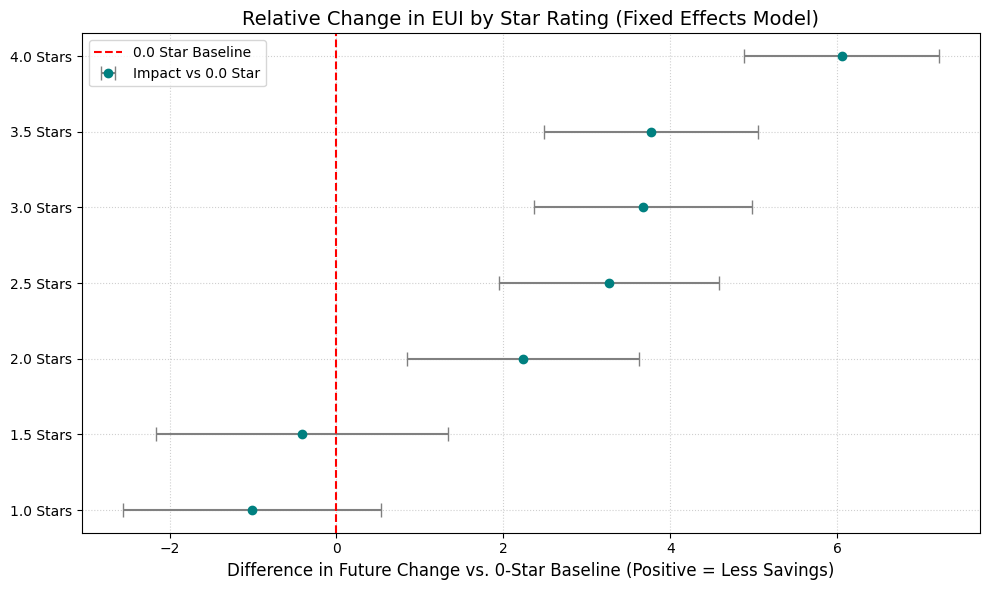

In [3]:
fig = plot_model_coefficients(fe_model)

This visualization plots the results showing that as star score increases the less the EUI savings there predicted to be. Such as, if a 1 star building decreases 10 Units for EUI then a 4 star building would be predicted to decrease 5 units for EUI. As 1 star buildings are around -1 and 4 star is around 6 units saved.